<a href="https://colab.research.google.com/github/jacky41788888/k-means/blob/main/%E6%A8%A1%E6%93%AC%E8%A3%BD%E7%A8%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import sqlite3
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 1000

# 1. 建立 1000 筆模擬原始資料
data = {
    'LOT_ID': [f'LOT_{i//25 + 1:03d}' for i in range(n_samples)],
    'UNIT_ID': [f'WFR_{i+1:04d}' for i in range(n_samples)],
    'CHAMBER_ID': np.random.choice(
        ['CHAMBER_A', 'CHAMBER_B', 'CHAMBER_C'],
        size=n_samples,
        p=[0.45, 0.35, 0.20],
    ),
    'STAGE_TEMP_C': np.round(
        np.random.normal(65.0, 2.5, n_samples), 2
    ),  # 載台溫度
    'CHAMBER_PRESSURE_MTORR': np.round(
        np.random.normal(30.0, 1.8, n_samples), 2
    ),  # 腔體真空度
    'RF_POWER_W': np.round(
        np.random.normal(850.0, 18.0, n_samples), 1
    ),  # 射頻功率
    'GAS_FLOW_SCCM': np.round(
        np.random.normal(120.0, 5.5, n_samples), 2
    ),  # 製程氣體流量
    'BIAS_VOLTAGE_V': np.round(
        np.random.normal(-220.0, 12.0, n_samples), 1
    ),  # 偏壓值
    'PROCESS_TIME_S': np.round(
        np.random.normal(45.0, 1.2, n_samples), 2
    ),  # 處理時間
    'SENSOR_VIBRATION_MMS': np.round(
        np.random.normal(1.8, 0.35, n_samples), 3
    ),  # 機台震動值
}

df_raw = pd.DataFrame(data)

# 2. 注入物理失效關聯邏輯 (溫度過高、真空不足與 CHAMBER_C 老化容易誘發缺陷)
risk_score = (
    (df_raw['STAGE_TEMP_C'] - 65.0) * 0.85
    + (30.0 - df_raw['CHAMBER_PRESSURE_MTORR']) * 0.75
    + (df_raw['RF_POWER_W'] - 850.0) * 0.04
    + (df_raw['CHAMBER_ID'] == 'CHAMBER_C') * 1.8
    + np.random.normal(0, 1.0, n_samples)
)

# 控制不良品比例約為 7% (符合高良率產線情境)
threshold = np.percentile(risk_score, 93)
df_raw['DEFECT_FLAG'] = (risk_score >= threshold).astype(int)

# 3. 模擬產線感測器斷訊缺值 (隨機注入約 1.5% NULL)
for col in ['GAS_FLOW_SCCM', 'SENSOR_VIBRATION_MMS']:
    null_mask = np.random.rand(n_samples) < 0.015
    df_raw.loc[null_mask, col] = np.nan

# 4. 轉換為指定的「三欄式」直式表格結構 (LOT_ID, 參數類別, 數值)
value_vars = [
    'STAGE_TEMP_C',
    'CHAMBER_PRESSURE_MTORR',
    'RF_POWER_W',
    'GAS_FLOW_SCCM',
    'BIAS_VOLTAGE_V',
    'PROCESS_TIME_S',
    'SENSOR_VIBRATION_MMS',
    'DEFECT_FLAG'
]

df_melted = pd.melt(
    df_raw,
    id_vars=['LOT_ID'],
    value_vars=value_vars,
    var_name='PARAMETER_NAME',
    value_name='PARAMETER_VALUE'
)

# 5. 儲存為本機 CSV 與 SQLite 資料庫
file_name = 'process_data_1000.csv'
df_melted.to_csv(file_name, index=False)

conn = sqlite3.connect('factory_mes.db')
df_melted.to_sql('wafer_process_log', conn, if_exists='replace', index=False)
conn.close()

print('已成功產出 1000 筆數據並轉化為三欄直式架構，已建立 factory_mes.db 及 CSV 檔案。')

# 6. 顯示前 10 筆轉換後的數據
print('\n=== 三欄直式表格數據預覽 (前 10 筆) ===')
print(df_melted.head(10).to_string(index=False))


已成功產出 1000 筆數據並轉化為三欄直式架構，已建立 factory_mes.db 及 CSV 檔案。

=== 三欄直式表格數據預覽 (前 10 筆) ===
 LOT_ID PARAMETER_NAME  PARAMETER_VALUE
LOT_001   STAGE_TEMP_C            65.44
LOT_001   STAGE_TEMP_C            61.66
LOT_001   STAGE_TEMP_C            65.95
LOT_001   STAGE_TEMP_C            66.53
LOT_001   STAGE_TEMP_C            66.40
LOT_001   STAGE_TEMP_C            67.70
LOT_001   STAGE_TEMP_C            67.08
LOT_001   STAGE_TEMP_C            66.15
LOT_001   STAGE_TEMP_C            64.82
LOT_001   STAGE_TEMP_C            60.85


=== 混淆矩陣 (Confusion Matrix) ===
[[182   4]
 [ 10   4]]

=== 分類成效報告 (Classification Report) ===
              precision    recall  f1-score   support

           0     0.9479    0.9785    0.9630       186
           1     0.5000    0.2857    0.3636        14

    accuracy                         0.9300       200
   macro avg     0.7240    0.6321    0.6633       200
weighted avg     0.9166    0.9300    0.9210       200


=== 製程特徵重要性排行 ===
                  Feature  Importance (%)
0            STAGE_TEMP_C           47.36
1  CHAMBER_PRESSURE_MTORR           18.86
2              RF_POWER_W           14.87
3    SENSOR_VIBRATION_MMS            4.95
4          PROCESS_TIME_S            4.93
5          BIAS_VOLTAGE_V            4.71
6           GAS_FLOW_SCCM            4.33


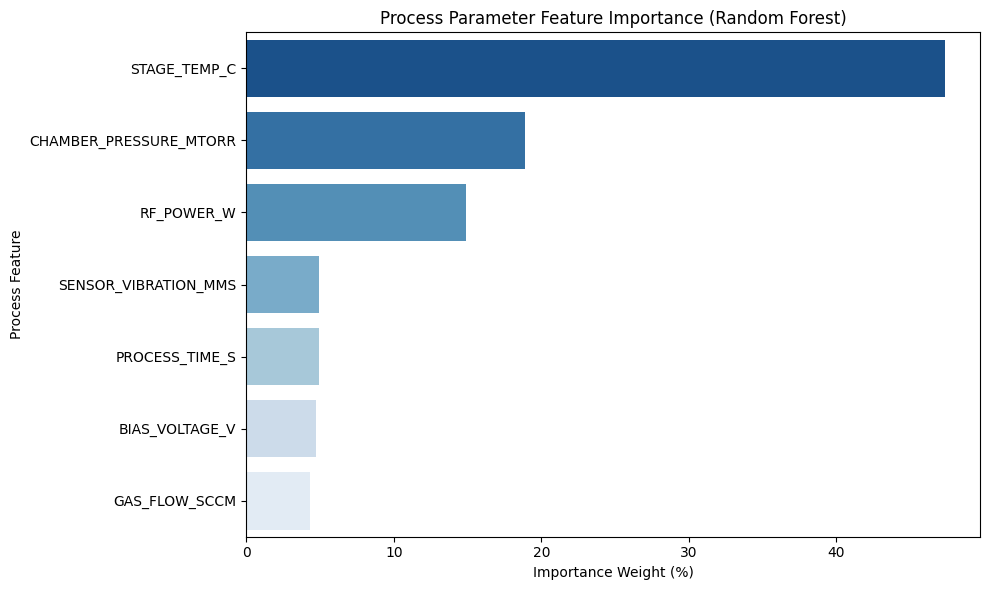

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. 讀取三欄直式數據
df_melted_load = pd.read_csv('process_data_1000.csv')

# 2. 修正對應分析格式：
# 由於每個 LOT_ID 有多個晶圓數據，我們需要為同一個 LOT_ID 內的相同參數依序編號，以重建唯一的 index
df_melted_load['SUB_ID'] = df_melted_load.groupby(['LOT_ID', 'PARAMETER_NAME']).cumcount()

# 進行 pivot 展開為寬表格
df = df_melted_load.pivot(
    index=['LOT_ID', 'SUB_ID'],
    columns='PARAMETER_NAME',
    values='PARAMETER_VALUE'
).reset_index()

# 3. 欄位分離：提取目標變數與特徵變數
target_col = 'DEFECT_FLAG'
ignore_cols = ['LOT_ID', 'SUB_ID', target_col]

X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
y = df[target_col]

# 4. 資料預處理
# (1) 類別型特徵自動轉 One-Hot 編碼（如果還有其他非數值欄位）
X = pd.get_dummies(X, drop_first=True)

# (2) 感測器缺值自動填補中位數
X = X.fillna(X.median(numeric_only=True))

# (3) 確保 target y 格式為整數整數型態（分類器需要）
y = y.astype(int)

# 5. 資料集切分 (80% 訓練, 20% 測試，stratify=y 確保不良品比例分佈一致)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. 建立隨機森林分類器
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

# 7. 模型成效評估
y_pred = rf.predict(X_test)

print('=== 混淆矩陣 (Confusion Matrix) ===')
print(confusion_matrix(y_test, y_pred))

print('\n=== 分類成效報告 (Classification Report) ===')
print(classification_report(y_test, y_pred, digits=4))

# 8. 提取特徵重要性排行 (Feature Importance)
importance_df = (
    pd.DataFrame(
        {
            'Feature': X.columns,
            'Importance (%)': (rf.feature_importances_ * 100).round(2),
        }
    )
    .sort_values(by='Importance (%)', ascending=False)
    .reset_index(drop=True)
)

print('\n=== 製程特徵重要性排行 ===')
print(importance_df.to_string())

# 9. 繪製特徵重要性長條圖並儲存
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance (%)',
    y='Feature',
    palette='Blues_r',
    hue='Feature',
    legend=False,
)
plt.title('Process Parameter Feature Importance (Random Forest)')
plt.xlabel('Importance Weight (%)')
plt.ylabel('Process Feature')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()

In [11]:
# 1. 取得模型預測的不良品機率 (Class 1 Probability)
df['DEFECT_PROB'] = rf.predict_proba(X)[:, 1]

# 2. 篩選出模型認為絕對安全 (預測不良率 == 0%) 的樣本
safest_samples = df[df['DEFECT_PROB'] == 0]

# 3. 輸出最佳製程視窗的統計邊界 (25% ~ 75% 區間與中位數)
# 確保我們只選擇當前 DataFrame 中確實存在的特徵欄位
features_to_describe = [col for col in ['STAGE_TEMP_C', 'CHAMBER_PRESSURE_MTORR', 'RF_POWER_W'] if col in safest_samples.columns]
golden_window = safest_samples[features_to_describe].describe()
print('=== 隨機森林判定之黃金製程視窗 ===')
print(golden_window.loc[['min', '25%', '50%', '75%', 'max']])

=== 隨機森林判定之黃金製程視窗 ===
PARAMETER_NAME  STAGE_TEMP_C  CHAMBER_PRESSURE_MTORR  RF_POWER_W
min                  57.8800                 27.1100     796.200
25%                  62.7150                 29.8200     832.325
50%                  64.1300                 30.7600     841.850
75%                  65.1475                 31.7175     852.650
max                  67.2100                 34.7200     884.600


anaconda單機使用程式碼

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. 讀取數據（已是標準寬表格）
df = pd.read_csv('process_data_1000.csv')

# 2. 欄位分離：排除非特徵的識別欄位與目標標籤
target_col = 'DEFECT_FLAG'
ignore_cols = ['LOT_ID', 'UNIT_ID', 'CHAMBER_ID', target_col]

feature_cols = [col for col in df.columns if col not in ignore_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

# 3. 資料預處理
# (1) 若有類別型特徵自動轉 One-Hot 編碼
X = pd.get_dummies(X, drop_first=True)

# (2) 數值型缺漏值自動填補中位數，並轉為 float32 節省記憶體
X = X.fillna(X.median(numeric_only=True)).astype(np.float32)

# (3) 確保目標 y 格式為整數型態（分類器需要）
y = y.fillna(0).astype(int)

# 4. 資料集切分 (80% 訓練, 20% 測試，stratify=y 保持不良率分佈一致)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. 建立隨機森林分類器（n_jobs=2 適合 8GB 記憶體平穩運作）
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=2
)

rf.fit(X_train, y_train)

# 6. 模型成效評估
y_pred = rf.predict(X_test)

print('=== 混淆矩陣 (Confusion Matrix) ===')
print(confusion_matrix(y_test, y_pred))

print('\n=== 分類成效報告 (Classification Report) ===')
print(classification_report(y_test, y_pred, digits=4))

# 7. 提取特徵重要性排行 (Feature Importance)
importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance (%)': (rf.feature_importances_ * 100).round(2),
    })
    .sort_values(by='Importance (%)', ascending=False)
    .reset_index(drop=True)
)

print('\n=== 製程特徵重要性排行 ===')
print(importance_df.to_string())

# 8. 繪製特徵重要性長條圖並儲存
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance (%)',
    y='Feature',
    palette='Blues_r',
    hue='Feature',
    legend=False,
)
plt.title('Process Parameter Feature Importance (Random Forest)')
plt.xlabel('Importance Weight (%)')
plt.ylabel('Process Feature')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()

KeyError: 'DEFECT_FLAG'